# Week 6 Day 2 - EDA

1. Data Collection
2. Data Cleaning
3. Univariate Analysis
4. **Bivariate Analysis**
5. **Multivariate Analysis**
6. **Time Series Data**
7. **Dealing with Outliers and Missing Values**

### Titanic dataset
https://www.kaggle.com/c/titanic/data

This datset was made for machine learning but provides some very interesting visualizations. I renamed the 'training' set as 'passengers' and  'gender_submission' file as 'survived'

In [138]:
import pandas as pd
import pickle

pull in the titanic_clean.csv from last class

In [140]:
#reading files
titanic_clean = pd.read_csv("data/titanic_clean.csv")

#or
with open('data/titanic_clean.pkl', 'rb') as f:
    titanicDf = pickle.load(f) # deserialize using load()


In [88]:
titanicDf

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinCode,AgeGroup
0,892,0,3,"Kelly, Mr. James",male,34.0,0,0,330911,7.8292,NaN,Q,None,Adult
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,None,Adult
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,None,Adult
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,None,Adult
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,None,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,None,NaN
419,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,C,Adult
420,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.0,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,None,Adult
421,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,None,NaN


[**seaborn**](https://seaborn.pydata.org)


Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics. You can find more on their [github repo](https://github.com/mwaskom/seaborn). 

In [90]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='Count'>

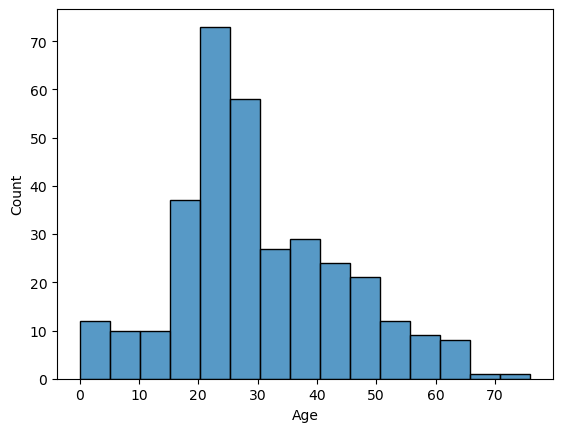

In [91]:
#use the histplot for a histogram
sns.histplot(titanicDf['Age'])

You can also add a  <u>kernel density estimate</u> - This function can normalize the statistic computed within each bin to estimate frequency. In statistics, kernel density estimation (KDE) is the application of kernel smoothing for probability density estimation. KDE answers a fundamental data smoothing problem where inferences about the population are made based on a finite data sample. 

<Axes: xlabel='Age', ylabel='Count'>

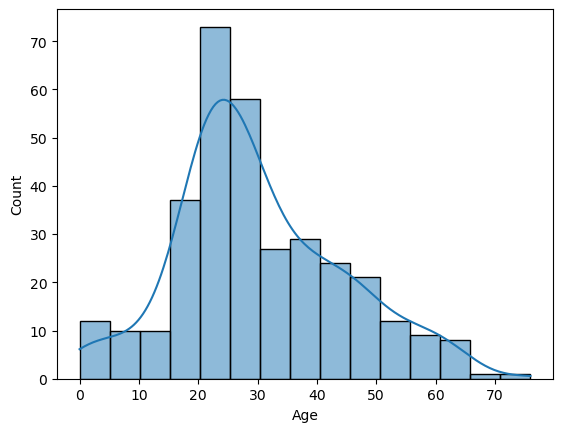

In [93]:
#add kde
sns.histplot(titanicDf['Age'], kde = True)

### Bivariate Analysis

**ScatterPlots**

A scatter plot identifies a possible relationship between changes observed in two different sets of variables. It provides a visual and statistical means to test the strength of a relationship between two variables

**Regression Plots**

**sns.regplot**

The regression plots in seaborn are primarily intended to add a visual guide that helps to emphasize patterns in a dataset during exploratory data analyses. Regression plots as the name suggests creates a regression line between 2 parameters and helps to visualize their linear relationships. 

<Axes: xlabel='Age', ylabel='Fare'>

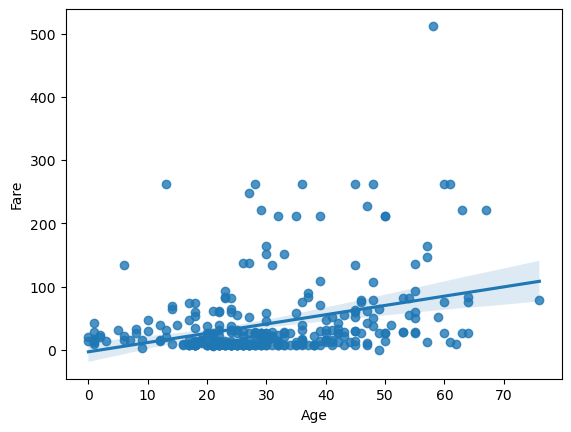

In [97]:
#plot fare and age
sns.regplot(
    x = "Age",
    y = "Fare",
    data = titanicDf
)

<Axes: xlabel='Pclass', ylabel='Fare'>

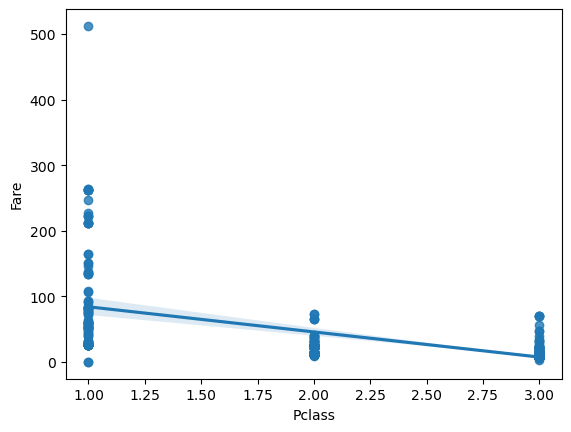

In [98]:
#plot plcass and fare
sns.regplot(
    x = "Pclass",
    y = "Fare",
    data = titanicDf
)

get rid of the outlier

In [100]:
#what datatype is it?
titanicDf["Fare"].dtype


dtype('float64')

In [101]:
#get is lesss than the outlier
fare_clean = titanicDf.loc[titanicDf["Fare"] < 400]
fare_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinCode,AgeGroup
0,892,0,3,"Kelly, Mr. James",male,34.0,0,0,330911,7.8292,NaN,Q,None,Adult
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,None,Adult
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,None,Adult
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,None,Adult
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,None,Adult


<Axes: xlabel='Pclass', ylabel='Fare'>

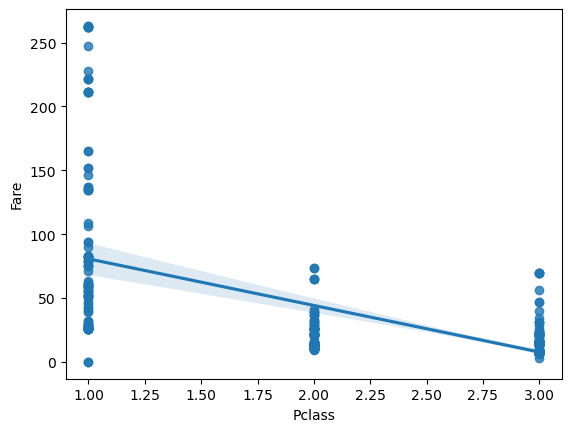

In [102]:
#try to plot it (fare and age)
sns.regplot(
    x = "Pclass",
    y = "Fare",
    data = fare_clean
)

<Axes: xlabel='Age', ylabel='Fare'>

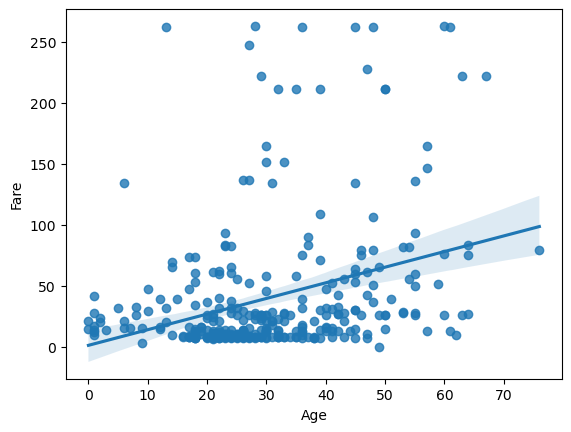

In [103]:
sns.regplot(
    x = "Age",
    y = "Fare",
    data = fare_clean
)

need to drop the other ones to match you can do it by just pulling form the clean df

[**Line Plots**](https://seaborn.pydata.org/generated/seaborn.lineplot.html)

A line graph connects individual data points that, typically, display quantitative values over a specified time interval.

**relplot**
Figure-level interface for drawing relational plots onto a FacetGrid.

This function provides access to several different axes-level functions that show the relationship between two variables with semantic mappings of subsets. The kind parameter selects the underlying axes-level function to use

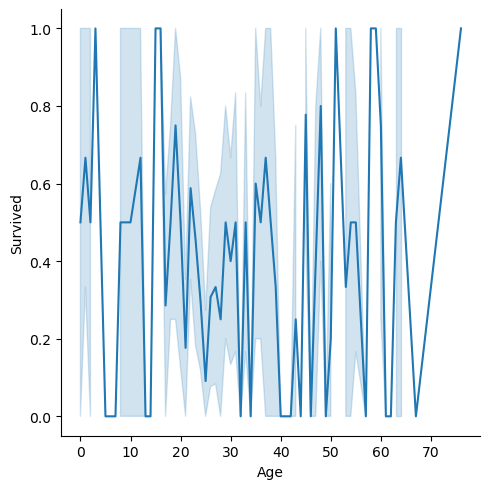

In [107]:
#plot age and survived
sns.relplot(
    x = "Age",
    y = "Survived",
    data = titanicDf,
    kind = 'line'
)

try to plot the inverse of them

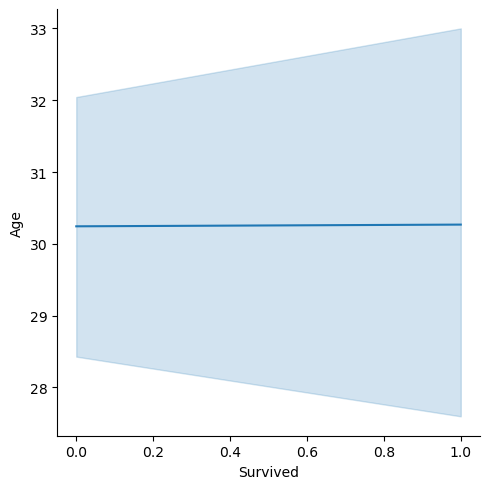

In [109]:
sns.relplot(
    x = "Survived",
    y = "Age",
    data = titanicDf,
    kind = 'line'
)

### [Box Plots](https://seaborn.pydata.org/generated/seaborn.boxplot.html)

A box and whisker plot or diagram (otherwise known as a boxplot), is a graph summarising a set of data. The shape of the boxplot shows how the data is distributed and it also shows any outliers. It is a useful way to compare different sets of data as you can draw more than one boxplot per graph.

<Axes: xlabel='Survived', ylabel='Age'>

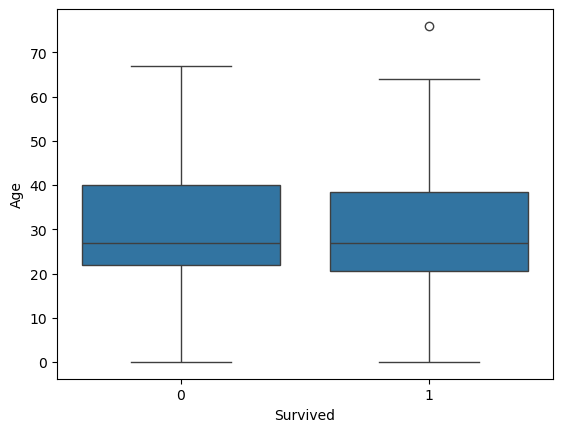

In [111]:
#plot survived and age
sns.boxplot(
    x = "Survived",
    y = "Age",
    data = titanicDf
)

<Axes: xlabel='Age', ylabel='Sex'>

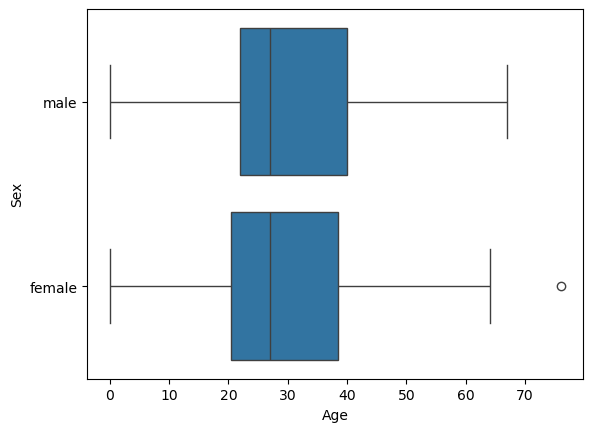

In [112]:
#plot sex and age
sns.boxplot(
    x = "Age",
    y = "Sex",
    data = titanicDf
)

<Axes: xlabel='Age', ylabel='Fare'>

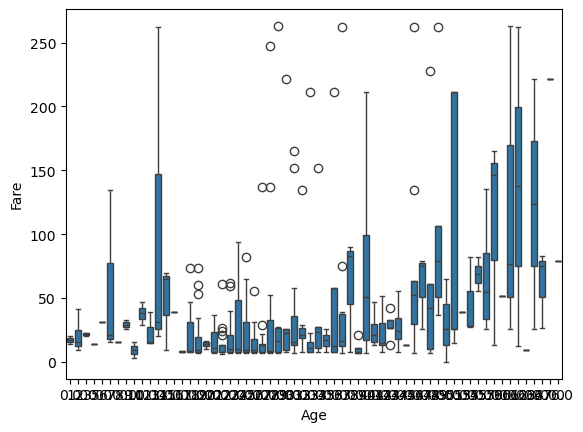

In [113]:
sns.boxplot(
    x = "Age",
    y = "Fare",
    data = fare_clean
)

## Exercise 1 

Lets compare the number of people in the group to the fare that they paid. 
- See if the number of people on board is related to the number of rooms they have
- If we assume the Fare is total - then 

In [115]:
titanicDf.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinCode,AgeGroup
0,892,0,3,"Kelly, Mr. James",male,34.0,0,0,330911,7.8292,NaN,Q,None,Adult
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,None,Adult
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,None,Adult
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,None,Adult
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,None,Adult


In [116]:
# find the total family
# make new data frame
titanicDf['TotalFamily'] = titanicDf['SibSp'] + titanicDf['Parch']+1
titanicDf.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinCode,AgeGroup,TotalFamily
0,892,0,3,"Kelly, Mr. James",male,34.0,0,0,330911,7.8292,NaN,Q,None,Adult,1
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,None,Adult,2
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,None,Adult,1
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,None,Adult,1
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,None,Adult,3


In [117]:
hasCabinDf = titanicDf[titanicDf["Cabin"].notnull()]
hasCabinDf.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinCode,AgeGroup,TotalFamily
13,904,1,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.0,1,0,21228,82.2667,B45,S,B,Adult,2
15,906,1,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,1,0,W.E.P. 5734,61.1750,E31,S,E,Adult,2
26,916,1,1,"Ryerson, Mrs. Arthur Larned (Emily Maria Borie)",female,48.0,1,3,PC 17608,262.3750,B57 B59 B63 B66,C,B,Adult,5
28,918,1,1,"Ostby, Miss. Helene Ragnhild",female,22.0,0,1,113509,61.9792,B36,C,B,Adult,2
30,920,0,1,"Brady, Mr. John Bertram",male,41.0,0,0,113054,30.5000,A21,S,A,Adult,1


In [118]:
hasCabinDf['Cabin'].unique()

array(['B45', 'E31', 'B57 B59 B63 B66', 'B36', 'A21', 'C78', 'D34', 'D19',
       'A9', 'D15', 'C31', 'C23 C25 C27', 'F G63', 'B61', 'C53', 'D43',
       'C130', 'C132', 'C101', 'C55 C57', 'B71', 'C46', 'C116', 'F',
       'A29', 'G6', 'C6', 'C28', 'C51', 'E46', 'C54', 'C97', 'D22', 'B10',
       'F4', 'E45', 'E52', 'D30', 'B58 B60', 'E34', 'C62 C64', 'A11',
       'B11', 'C80', 'F33', 'C85', 'D37', 'C86', 'D21', 'C89', 'F E46',
       'A34', 'D', 'B26', 'C22 C26', 'B69', 'C32', 'B78', 'F E57', 'F2',
       'A18', 'C106', 'B51 B53 B55', 'D10 D12', 'E60', 'E50', 'E39 E41',
       'B52 B54 B56', 'C39', 'B24', 'D28', 'B41', 'C7', 'D40', 'D38',
       'C105'], dtype=object)

In [119]:
hasCabinDf['Cabin'].value_counts()

Cabin
B57 B59 B63 B66    3
B45                2
C89                2
C55 C57            2
A34                2
                  ..
E52                1
D30                1
E31                1
C62 C64            1
C105               1
Name: count, Length: 76, dtype: int64

In [120]:
hasCabinDf['NumofCabins'] = hasCabinDf['Cabin'].split(''.astype('str').tolist()
hasCabinDf['NumofCabins'] = hasCabinDf['Cabin'].apply(leen)
hasCabinDf.head()

SyntaxError: '(' was never closed (3443751213.py, line 1)

In [ ]:
# # hasCabinDf['NumofCabinsLyst'] = hasCabinDf['Cabin'].astype('str').tolist()
# hasCabinDf['NumofCabinsLyst'] = hasCabinDf['Cabin'].apply(lambda x: [x])

# # hasCabinDf['NumofCabinsLyst'].dtype

# hasCabinDf['NumofCabins'] = hasCabinDf['NumofCabinsLyst'].apply(len)
# hasCabinDf.head()

In [ ]:
hasCabinDf['NumofCabinsLyst'] = hasCabinDf['Cabin'].str.split(' ')

hasCabinDf['NumofCabins'] = hasCabinDf['NumofCabinsLyst'].apply(len)
hasCabinDf.head()

In [ ]:
sns.regplot(
    x = "Fare",
    y = 'NumofCabins',
    data = hasCabinDf
)

In [ ]:
sns.regplot

In [ ]:
sns.regplot(
    x = "NumofCabins",
    y = 'Fare',
    data = hasCabinDf
)

### Multivariate Analysis

**Pivot Tables**

A PivotTable is an interactive way to quickly summarize large amounts of data. You can use a PivotTable to analyze numerical data in detail, and answer unanticipated questions about your data.


In [ ]:
import numpy as np

In [ ]:
#checkout the data again
titanicDf.head()


In [ ]:
# lets make a pivot table of both fare and index isname
#autotmaticallly aggigrages  by mean
titanicDf.pivot_table(values = "Age", index = "Sex")


**aggfunc**

aggfuncfunction, list of functions, dict, default “mean”

If a list of functions is passed, the resulting pivot table will have hierarchical columns whose top level are the function names (inferred from the function objects themselves). If a dict is passed, the key is column to aggregate and the value is function or list of functions. If margin=True, aggfunc will be used to calculate the partial aggregates.

In [ ]:
# group them by the aggregates values of the sum of all of those values- names with the same age
# lists with the same number
# how many of the same one 
titanicDf.pivot_table(values = "Age", index = "Sex", aggfunc = np.sum)


In [ ]:
# group them by mean and median
titanicDf.pivot_table(values = "Age", index = "Sex", aggfunc = [np.mean, np.median])

In [ ]:
#add the element of age group 
titanicDf.pivot_table(values = "Fare", index = "Sex", columns = "AgeGroup")


**lmplot**

lmplot() combines regplot() and FacetGrid.

The FacetGrid class helps in visualizing the distribution of one variable as well as the relationship between multiple variables separately within subsets of your dataset using multiple panels.

lmplot() is more computationally intensive and is intended as a convenient interface to fit regression models across conditional subsets of a dataset.

In [ ]:
#plot fare, age, and agegroup
sns.lmplot(
    x = "Fare",
    y = "Age",
    hue = "AgeGroup",
    data = titanicDf
)

[**heatmaps**](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

Plot rectangular data as a color-encoded matrix.

Heatmaps (or heat maps) are visual representations of data where values are depicted by color, making it easy to visualize complex data and understand it at a glance. Heatmaps can be created by hand, though modern heatmaps are generally created using specialized heatmapping software.


In [ ]:
titanicDf.head()

In [ ]:
#make a subset of the titanic_clean with two variables
subset = titanicDf[['PassengerId', 'Age']]

In [ ]:
#make the heatmap
sns.heatmap(subset)

In [ ]:
subset.head()

In [ ]:
#set the index
subset = subset.set_index("PassengerId")

In [ ]:
subset

In [ ]:
#map it again
sns.heatmap(subset)

In [ ]:
# add another variable
subset = titanicDf[["PassengerId", "Age", "Fare"]]
subset = subset.set_index('PassengerId')
subset.head()

In [ ]:
sns.heatmap(subset)

In [ ]:
#clean it up a tad
subset = fare_clean[["PassengerId", "Age", "Fare"]]
subset = subset.set_index('PassengerId')
sns.heatmap(subset)

#### Dealing with Outliers and Missing Values

##### <u>Remember:</u>

**Removing Outliers-------------**

The outlier affects both results and assumptions
In some cases, removing outliers may be perceived as data manipulation or cherry-picking results to support a particular narrative.

Treat outliers like children … correct them when needed but never throw them out. Environmental field data (water, air, soils, rock, biota) are usually skewed distributions, not following a normal distribution. There are physical reasons for this. Outliers are to be expected.

**Managing Missing Data----------------**

They reduce the sample size and statistical power. More missing data means a higher chance of bias. It also makes it harder to draw reliable conclusions.

Deletion is the most frequently used method in handling missing data, and thus has become the default option for analysis in most statistical software packages. A deletion is known to produce unbiased estimates and conservative results. 

Note:

*Cannot convert non-finite values (NA or inf) to integer*

*Missing data Can be represented as NA , nan , 0 , . ...*

In [156]:
# Return missing values in the Age column

# titanicDf["Age"].isna()
titanicDf["Age"].isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
418     True
419    False
420    False
421     True
422     True
Name: Age, Length: 418, dtype: bool

In [158]:
# Get summary of missingness
titanicDf["Age"].isna().sum()

86

[**missingno**](https://github.com/ResidentMario/missingno)

missingno (shorthand msno) is a glitch Pokemon. It's also the name of a Python library for the exploratory visualization of missing data.

missingno provides a small toolset of flexible and easy-to-use missing data visualizations and utilities that allows you to get a quick visual summary of the completeness (or lack thereof) of your dataset.

In [166]:
#if you need it
# pip install missingno


In [174]:
import missingno as msno

In [170]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


[**matplotlib**](https://matplotlib.org/stable/users/index.html)

Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. Matplotlib makes easy things easy and hard things possible.

[**matplotlib.pyplot**](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html)

matplotlib.pyplot is a state-based interface to matplotlib. It provides an implicit, MATLAB-like, way of plotting. It also opens figures on your screen, and acts as the figure GUI manager.

pyplot is mainly intended for interactive plots and simple cases of programmatic plot generation

In [176]:
import matplotlib.pyplot as plt

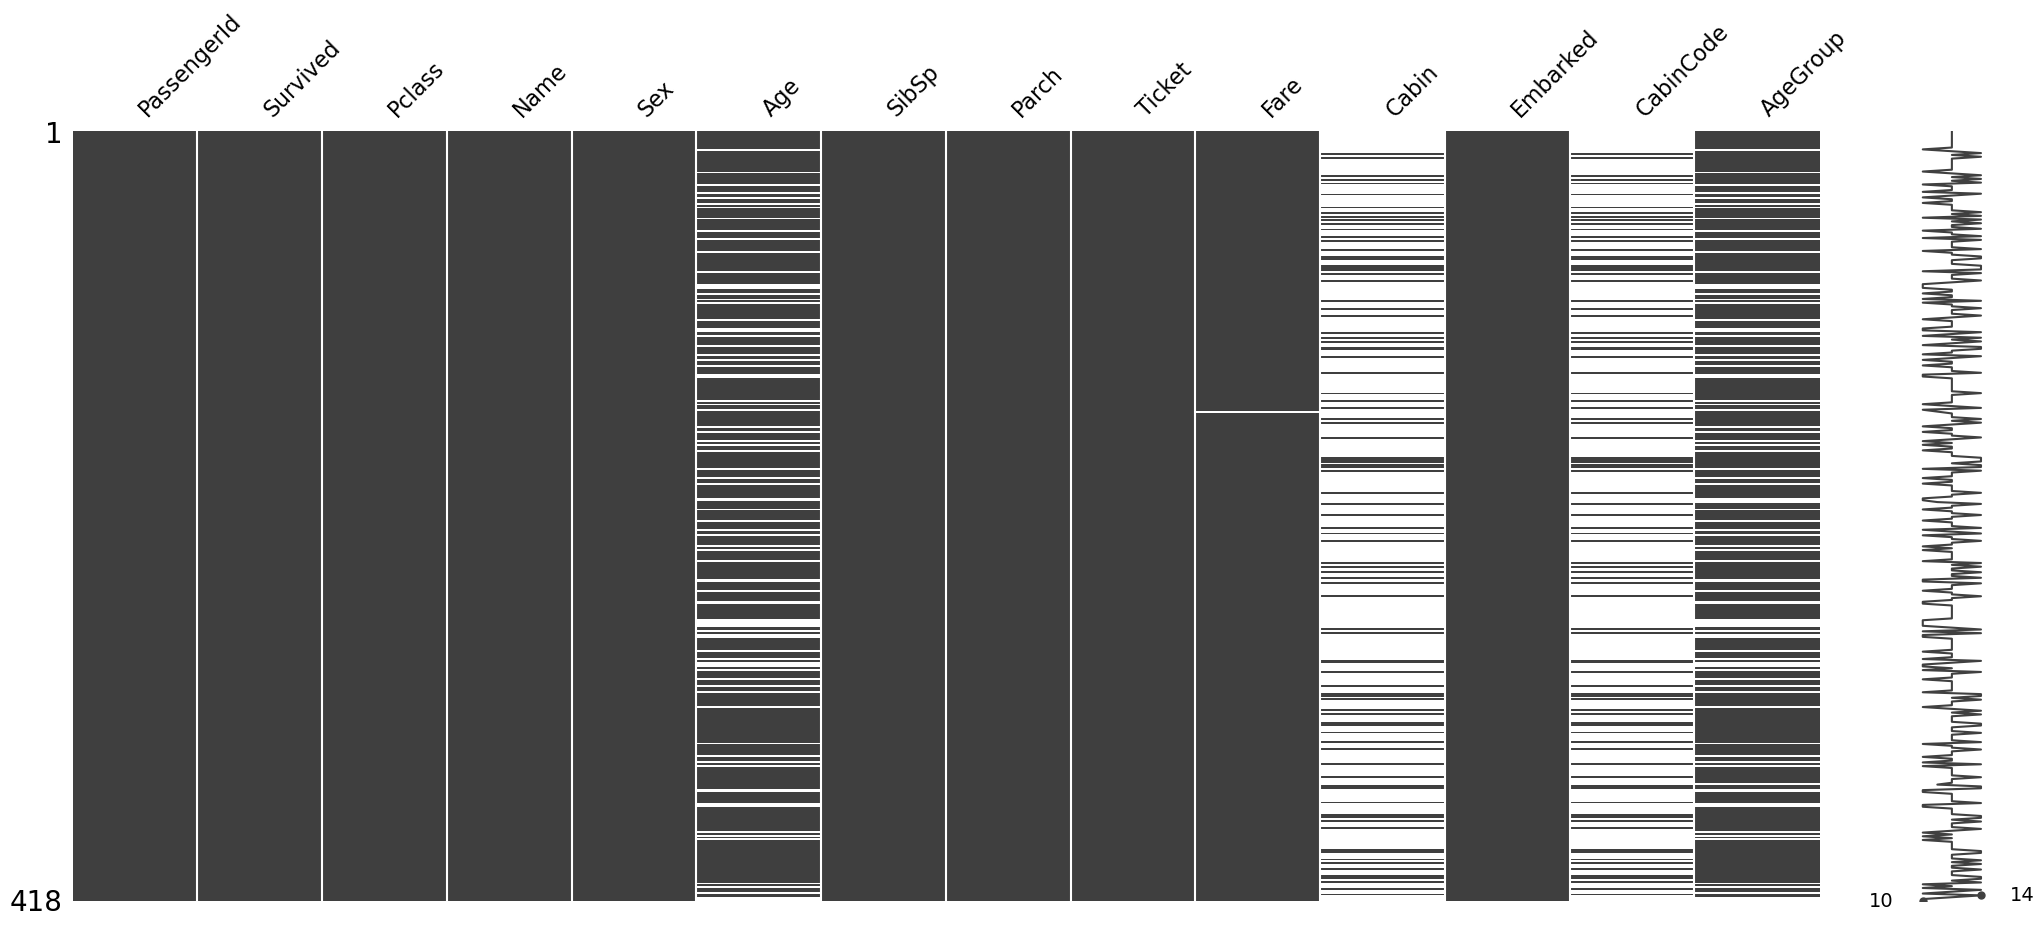

In [178]:
#check out the missingno for the whole dataset
msno.matrix(titanicDf)
plt.show()

#### Dropping missing data

In [144]:
len(titanicDf)

418

In [148]:
#drop the na from age
titanic_clean_dropped = titanicDf.dropna(subset = ["Age"])
len(titanic_clean_dropped)

332

In [152]:
#what percentage of the na subset
(len(titanicDf) - len(titanic_clean_dropped))/(len(titanicDf)) *100

20.574162679425836

#### Replacing with statistical measures

In [154]:
#get the age mean
age_mean = titanicDf["Age"].mean()
age_mean

30.253012048192772

In [180]:
#fill the na with the average
titanicDf = titanicDf.fillna({"Age":age_mean})

In [182]:
#check for missing values
titanicDf['Age'].isna().sum()

0

In [184]:
titanicDf.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinCode,AgeGroup
0,892,0,3,"Kelly, Mr. James",male,34.0,0,0,330911,7.8292,NaN,Q,None,Adult
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,None,Adult
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,None,Adult
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,None,Adult
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,None,Adult


In [186]:
#Now we try to convert the age to integer
titanicDf["Age"] = titanicDf["Age"].astype('int')

In [188]:
# look at dtypes
titanicDf.dtypes

PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex              object
Age               int32
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked         object
CabinCode        object
AgeGroup       category
dtype: object

<Axes: >

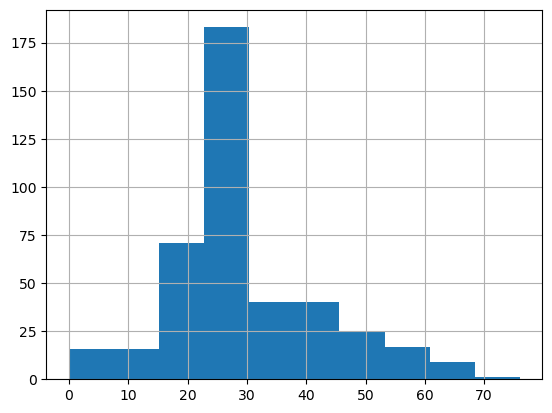

In [190]:
#plotting age - histogram
titanicDf["Age"].hist()

### Timeseries Analysis

Time series analysis is a specific way of analyzing a sequence of data points collected over an interval of time. In time series analysis, analysts record data points at consistent intervals over a set period of time rather than just recording the data points intermittently or randomly.

Weather records, economic indicators and patient health evolution metrics—all are time series data.

this should look familiar. [wikifunctions](https://github.com/brianckeegan/wikifunctions) is a coding package from Professor Brian Keegan here at C U Boulder

In [192]:
import wikifunctions as wf

get all of the page views of a page over time

In [194]:
pvs = wf.get_pageviews("Denver Broncos")
pvs.head()

timestamp
2015-07-01    937
2015-07-02    932
2015-07-03    825
2015-07-04    824
2015-07-05    852
Name: views, dtype: int64

<Axes: xlabel='timestamp'>

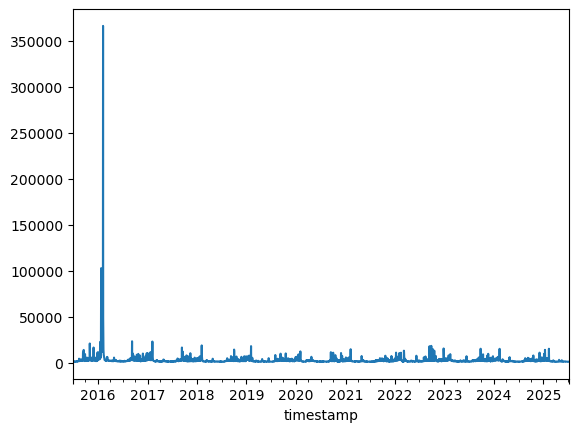

In [196]:
#plot it
pvs.plot()

Compare two pagess

In [198]:
pvs1 = wf.get_pageviews("Kansas City Chiefs")
pvs2 = wf.get_pageviews("Philadelphia Eagles")

<Axes: xlabel='timestamp'>

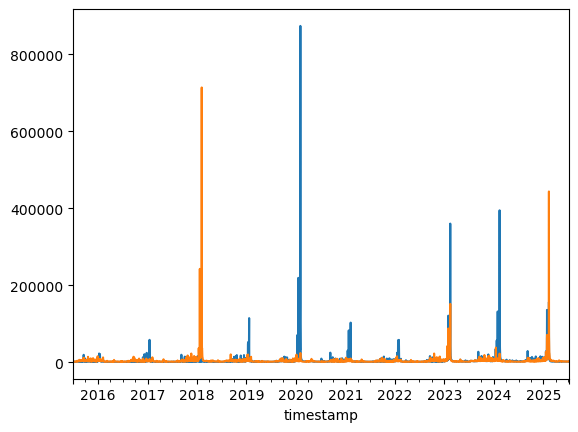

In [200]:
#plot both
pvs1.plot(label = "Chiefs")
pvs2.plot(label = "Eagles")

We need to change the scale 

Scales are functions that map from an input domain to an output range. The values in any dataset are unlikely to correspond exactly to pixel measurements for use in your visualization. Scales provide a convenient way to map those data values to new values useful for visualization purposes.

**linear scale**

Linear charts become useful when you want to see the pure price changes with scaling calculations. Day traders often prefer linear charts. -- this is what you automatically look at. 

**log scale**

A logarithmic scale, often called a log scale, shows the percentage (relative) change. If an asset rises from 50 to 60, a rise of 20%, it’s presented in the same way as a change from 10 000 to 12 000 (also a 20% rise). The distance between the lower numbers is higher than the upper numbers. Why does it change? Because the log scale shows the percentage changes (relative changes) – not absolute changes. A rise from 120 to 140 is much bigger relatively than a rise from 320 to 340, even though both rise 20 points.

A logarithmic scale can easily render values from 10 to 100000 on the same chart. In contrast, if you use any other conventional chart, such as a simple line series with a linear axis, you will not notice details correlating with the smallest values, which could lead to misinterpretation of the data set.


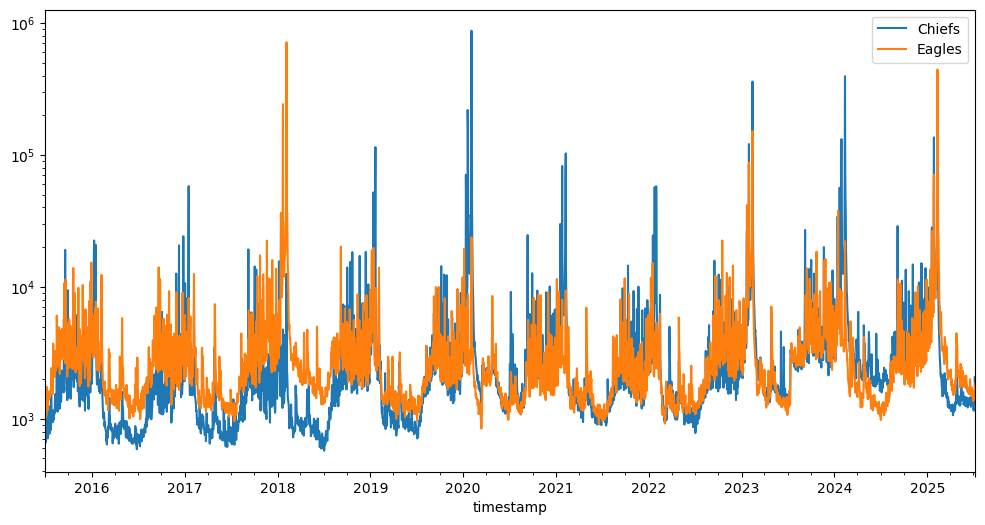

In [202]:
#we're going to use more of matplotlib
#f is for figure
#ax is the keyword for the part of the overall figure in which a chart/plot is drawn. 
f , ax = plt.subplots(1,1, figsize = (12,6))
#get both of the plots
pvs1.plot(label = "Chiefs", logy = False, ax=ax)
pvs2.plot(label = "Eagles", logy = False, ax=ax)

#set a new scale
ax.set_yscale('log')
#include a legend
ax.legend()

Get the revisions of a page

In [204]:
revs_df = wf.get_all_page_revisions('Aaron Rodgers')

revs_df.head()

,revid,parentid,user,anon,userid,timestamp,size,sha1,comment,commenthidden,page,date,diff,lag,age
0,8833326,0,63.202.181.53,True,0,2004-12-16 06:03:42+00:00,119,30fb5a6bebf99ba25f82c5a4736c01cc944400d7,,NaN,Aaron Rodgers,2004-12-16,NaN,NaN,0.000000
1,9355759,8833326,Oliver Lineham,NaN,83708,2004-12-26 17:01:22+00:00,191,dbe2cd82cc6400c927c1beb7c6750d31cbed89b4,categorise,NaN,Aaron Rodgers,2004-12-26,72.0,903460.0,10.456713
2,9355768,9355759,The Riddler,NaN,148283,2005-01-14 08:20:04+00:00,271,ac9866e521bd5e454a294d1c1a0fb2ff52d04a35,,NaN,Aaron Rodgers,2005-01-14,80.0,1610322.0,29.094699
3,9355801,9355768,The Riddler,NaN,148283,2005-01-14 08:20:30+00:00,270,57632eddee30f9a8f321ce6ed1e907424a3bf09a,,NaN,Aaron Rodgers,2005-01-14,-1.0,26.0,29.095000
4,9366999,9355801,The Riddler,NaN,148283,2005-01-14 08:22:40+00:00,366,e36b5e3d650ad199191201b38d6ce73397a3fef2,,NaN,Aaron Rodgers,2005-01-14,96.0,130.0,29.096505


**pd.groupby**

A groupby operation involves some combination of splitting the object, applying a function, and combining the results. This can be used to group large amounts of data and compute operations on these groups.

In [206]:
import pandas as pd

C:\Users\luxni\AppData\Local\Temp\ipykernel_21008\3508345942.py:2: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  revs_df.groupby(pd.Grouper(key = 'timestamp', freq = 'm')).agg({'sha1': 'nunique'})['sha1'].plot()


<Axes: xlabel='timestamp'>

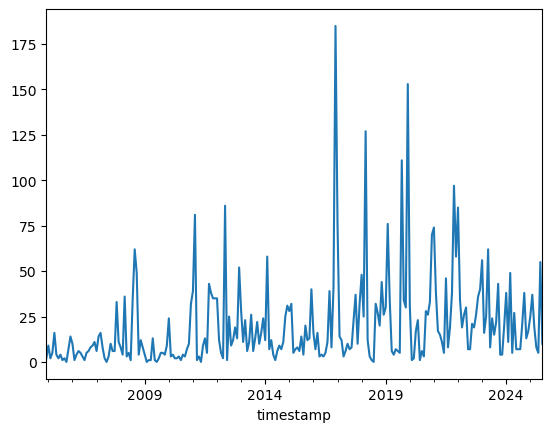

In [208]:
#group the revisions by month
revs_df.groupby(pd.Grouper(key = 'timestamp', freq = 'm')).agg({'sha1': 'nunique'})['sha1'].plot()


### Save our Image(s)

pandas save fig - fig.savefig()

C:\Users\luxni\AppData\Local\Temp\ipykernel_21008\3106984993.py:3: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  ax = revs_df.groupby(pd.Grouper(key = 'timestamp', freq = 'm')).agg({'sha1': 'nunique'})['sha1'].plot()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\luxni\\OneDrive\\Documents\\GitHub\\summer_notes_CMM\\figures\\M_Revisions.jpg'

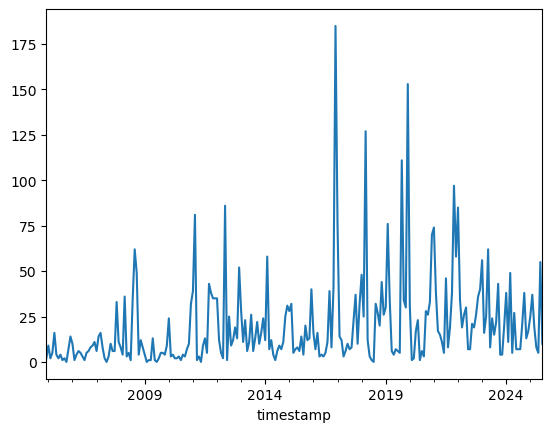

In [212]:
#get the monthly revision data from before 

ax = revs_df.groupby(pd.Grouper(key = 'timestamp', freq = 'm')).agg({'sha1': 'nunique'})['sha1'].plot()

fig = ax.get_figure()
fig.savefig("figures/M_Revisions.jpg")

In [214]:
import matplotlib.pyplot as plt

matplotlib save fig - plt.savefig()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\luxni\\OneDrive\\Documents\\GitHub\\summer_notes_CMM\\figures\\chiefs_eagles_pvs.png'

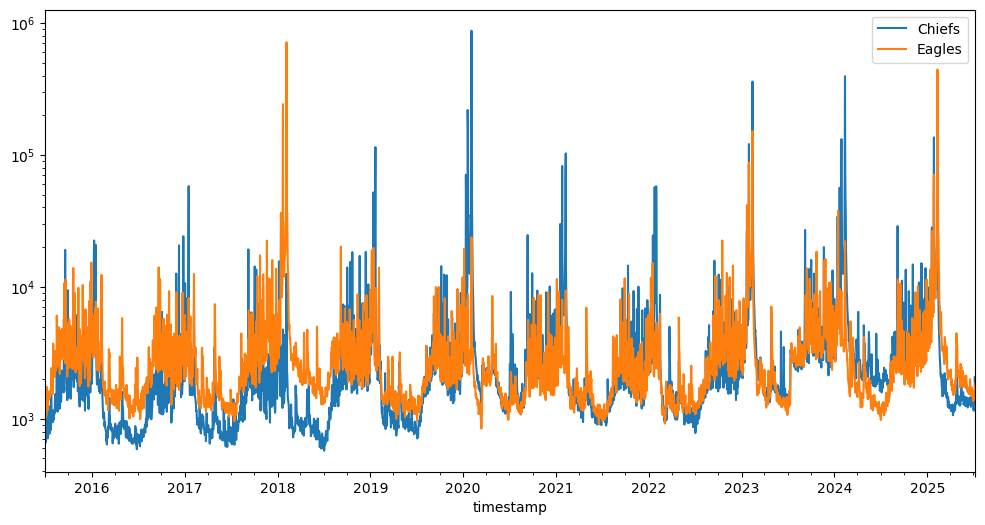

In [216]:


#save the image
#we're going to use more of matplotlib
#f is for figure
#ax is the keyword for the part of the overall figure in which a chart/plot is drawn. 
f , ax = plt.subplots(1,1, figsize = (12,6))

#get both of the plots
pvs1.plot(label = "Chiefs", logy = False, ax=ax)
pvs2.plot(label = "Eagles", logy = False, ax=ax)

#set a new scale
ax.set_yscale('log')

#include a legend
ax.legend()

plt.savefig("figures/chiefs_eagles_pvs.png")
